# XGBoost

In [ ]:
from datetime import datetime
from scipy.sparse import load_npz, hstack
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
X_train = load_npz('datasets/X_train.npz')
X_test = load_npz('datasets/X_test.npz')
X_extra_train = pd.read_csv('datasets/X_extra_train.csv')
X_extra_test = pd.read_csv('datasets/X_extra_test.csv')

y_train = pd.read_csv('datasets/y_train.csv')['label']
y_test = pd.read_csv('datasets/y_test.csv')['label']

In [12]:
ohe = OneHotEncoder(drop='first', handle_unknown='ignore')
scaler_num = StandardScaler(with_mean=False)
scaler_tfidf = StandardScaler(with_mean=False)

tf = ColumnTransformer(transformers=[
    ('bin', 'passthrough', ['has_link', 'domain_dot_high', 'has_suspicious_tags']),
    ('cat', ohe, ['words_count_cat']),
    ('num', scaler_num, ['imperative_verbs_count', 'pronoun_density', 'urgency_markers_count'])
],
remainder='drop')

X_train = scaler_tfidf.fit_transform(X_train)
X_test = scaler_tfidf.transform(X_test)

X_extra_train = tf.fit_transform(X_extra_train)
X_extra_test = tf.transform(X_extra_test)

X_train = hstack([X_train, X_extra_train])
X_test = hstack([X_test, X_extra_test])

In [13]:
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    reg_lambda=1
)

start_train = datetime.now()
xgb_model.fit(X_train, y_train)
train_duration = datetime.now() - start_train

start_pred = datetime.now()
y_pred = xgb_model.predict(X_test)
predict_duration = datetime.now() - start_pred

#### Métricas

Se evalúa.

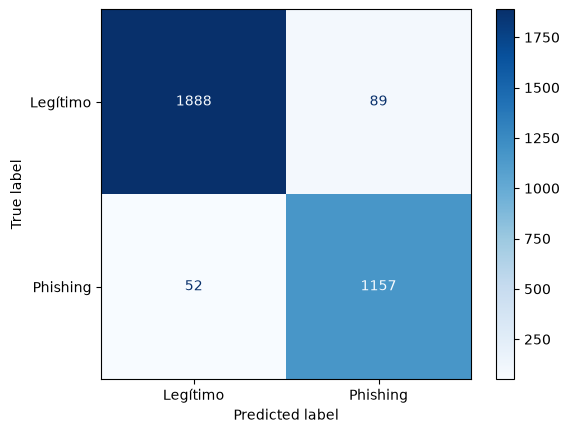

In [14]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [15]:
cm_xgb = confusion_matrix(y_test, y_pred)
P = cm_xgb[1, :].sum()
N = cm_xgb[0, :].sum()
TP = cm_xgb[1, 1]
TN = cm_xgb[0, 0]

TPR_xgb = TP / P
TNR_xgb = TN / N
balanced_accuracy_xgb = (TPR_xgb + TNR_xgb) / 2

precision_xgb = precision_score(y_test, y_pred, zero_division=0)
recall_xgb = recall_score(y_test, y_pred, zero_division=0)
f1_xgb = f1_score(y_test, y_pred, zero_division=0)

print(f"Exactitud balanceada:    {balanced_accuracy_xgb:.4f}")
print(f"Precisión:               {precision_xgb:.4f}")
print(f"Sensibilidad (Recall):   {TPR_xgb:.4f}")
print(f"F1-score:                {f1_xgb:.4f}")
print(f"Especificidad:           {TNR_xgb:.4f}")
print(f"Recuperación (Recall):   {recall_xgb:.4f}")
print(f"Tiempo de entrenamiento: {train_duration}")
print(f"Tiempo de predicción:    {predict_duration}")

Exactitud balanceada:    0.9560
Precisión:               0.9286
Sensibilidad (Recall):   0.9570
F1-score:                0.9426
Especificidad:           0.9550
Recuperación (Recall):   0.9570
Tiempo de entrenamiento: 0:00:50.082048
Tiempo de predicción:    0:00:00.021679


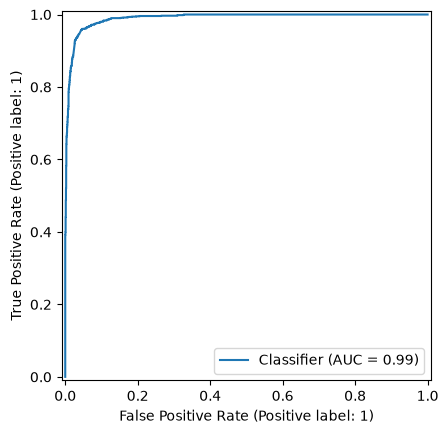

In [16]:
y_scores = xgb_model.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_scores)

Sospechosamente bueno. Probamos con CV para evitar overfitting.

In [17]:
cv_xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    reg_lambda=1
)

predicts = cross_val_predict(cv_xgb_model, X_train, y_train, cv=10, n_jobs=-1)

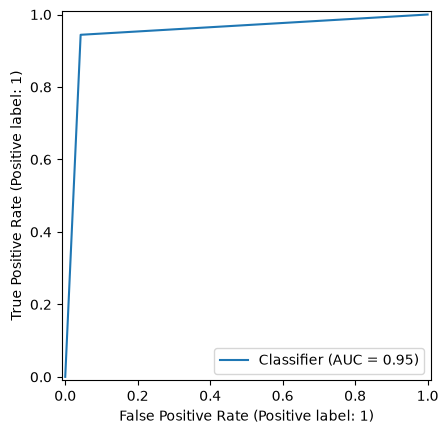

In [18]:
RocCurveDisplay.from_predictions(y_train, predicts)

In [20]:
print(f"AUC: {roc_auc_score(y_test, y_scores):.4f}")

AUC: 0.9899


Muy bien.